# Shapelet experiments notebook

This notebook is for **exploration, experimentation, and visualisation** with shapelets on the **2023 household energy series**.

## Why this notebook exists
Shapelets are useful here because they can reveal **local temporal motifs** such as:
- short bursts
- near-zero stretches
- repeated weekly patterns
- local peaks or dips

This notebook does **not** assume classical supervised shapelets.  
Instead, it uses an **unsupervised, shapelet-inspired workflow** for:
1. loading 2023 series
2. visual inspection
3. sampling candidate local motifs
4. scoring and selecting diverse shapelets
5. transforming households into shapelet-distance features
6. clustering in shapelet space
7. visualising and interpreting the results

## Recommendation on data choice
For shapelets, the **z-normalised full time series** is usually the best starting point:
- better than raw if we want to focus on **shape rather than magnitude**
- better than the engineered feature table if we want to discover **local motifs inside the series**

So this notebook is set up to use our **z-normalised 2023 parquet/csv** as the main input.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import math
import random
import time
from joblib import Parallel, delayed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler


## 1. Configuration

Setting the paths to our local files.


In [2]:
# Main input: prefer the z-normalised 2023 dataset
INPUT_PATH = Path("../data/processed/sample_23_znorm.parquet")

# Optional alternatives:
# INPUT_PATH = Path("data/raw/sample_23.csv")

# Optional feature table
FEATURE_TABLE_PATH = Path("../data/processed/feature_based_clusters_2023_refined.csv")

OUTPUT_DIR = Path("outputs/shapelet_experiments")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 69
rng = np.random.default_rng(SEED)
random.seed(SEED)

# ============================================================================
# EXPLORATION MODE: Set to True to test on a subsample (faster prototyping)
#                   Set to False to run on the full 14k household dataset
# ============================================================================
EXPLORATION_MODE = False
EXPLORATION_SUBSAMPLE_SIZE = 5000  # Number of households to use in exploration mode

# Candidate shapelet settings
# REDUCED from 120 to 40 to cut scoring time by ~3x (still maintains diversity)
SHAPELET_LENGTHS = [7, 14, 30, 60]
CANDIDATES_PER_LENGTH = 80
TOP_SHAPELETS_PER_LENGTH = 5
MAX_TOTAL_SHAPELETS = 20
SIMILARITY_THRESHOLD = 0.92

# Cluster search
# REDUCED from range(2,9) to range(2,7) and n_init from 20 to 5
# Still robust for 14k samples but much faster
K_RANGE = range(2, 7)
FINAL_CLUSTERER = "kmeans"   # or "kmeans"


## 2. Load the dataset

Expected structure:
- first column: `ID`
- remaining columns: daily time steps of 2023


In [3]:
def load_table(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix == ".parquet":
        return pd.read_parquet(path)
    raise ValueError(f"Unsupported file type: {path.suffix}")

df = load_table(INPUT_PATH)
display(df.head())

id_col = df.columns[0]
value_cols = df.columns[1:]

ids = df[id_col].copy()
X_df = df[value_cols].astype(float).copy()
print(f"Loaded: {INPUT_PATH}")
# ============================================================================
# Optional subsample for fast exploration
# ============================================================================
if EXPLORATION_MODE:
    n_total = len(df)
    subsample_idx = rng.choice(n_total, size=min(EXPLORATION_SUBSAMPLE_SIZE, n_total), replace=False)
    ids = ids.iloc[subsample_idx].reset_index(drop=True)
    X_df = X_df.iloc[subsample_idx].reset_index(drop=True)
    print(f"EXPLORATION MODE ACTIVE: Using {len(ids)} / {n_total} households")
else:
    print(f"Running on FULL DATASET: {len(ids)} households")

print(f"Households: {len(df)}")
print(f"Households: {len(ids)}")


,ID,2023-01-01,2023-01-02,2023-01-03,2023-01-04,2023-01-05,2023-01-06,2023-01-07,2023-01-08,2023-01-09,...,2023-12-22,2023-12-23,2023-12-24,2023-12-25,2023-12-26,2023-12-27,2023-12-28,2023-12-29,2023-12-30,2023-12-31
0,22,0.408763,-0.600259,-0.430872,-0.221466,0.576640,-0.081024,-1.029640,-0.447232,-0.671738,...,-0.867804,-0.002749,-1.096590,0.054888,0.170162,-0.622156,-0.571063,-1.168573,-0.814194,0.229309
1,42,1.707805,1.863012,1.392012,1.269883,1.416332,0.780683,0.497334,1.496890,1.541151,...,1.193124,1.707331,1.039237,0.917108,0.594035,0.587335,1.282914,0.751826,0.978568,1.975064
2,56,0.667588,0.708276,0.623830,1.450632,0.524222,0.572395,1.745425,1.491896,0.495050,...,1.216295,1.320509,1.648888,2.151341,1.010170,-0.419461,-1.049351,-0.134840,0.968331,-0.219286
3,58,0.136024,-0.318838,0.430069,-0.242682,0.204811,-0.518585,-0.132887,1.142883,-0.103407,...,0.912900,2.034655,0.839389,1.004742,2.207756,3.020915,-0.770111,0.737342,0.867168,1.358125
4,64,1.030048,-0.022636,-0.817005,0.589164,-0.622783,0.855248,-0.927711,-0.539267,-0.354756,...,0.127886,0.651315,-0.817005,-0.634824,-0.634824,-0.634824,-0.634824,-0.634824,-0.139169,0.563915


Loaded: ../data/processed/sample_23_znorm.parquet
Running on FULL DATASET: 17547 households
Households: 17547
Households: 17547


## 3. Check whether the input is already z-normalised

If the input is already a z-normalised parquet/csv, the per-row means should be around 0 and the per-row standard deviations around 1.

If you load a raw dataset instead, the notebook can z-normalise it below.


Average of row means: -2.3061814463060826e-18
Average of row stds : 0.9912235709807944


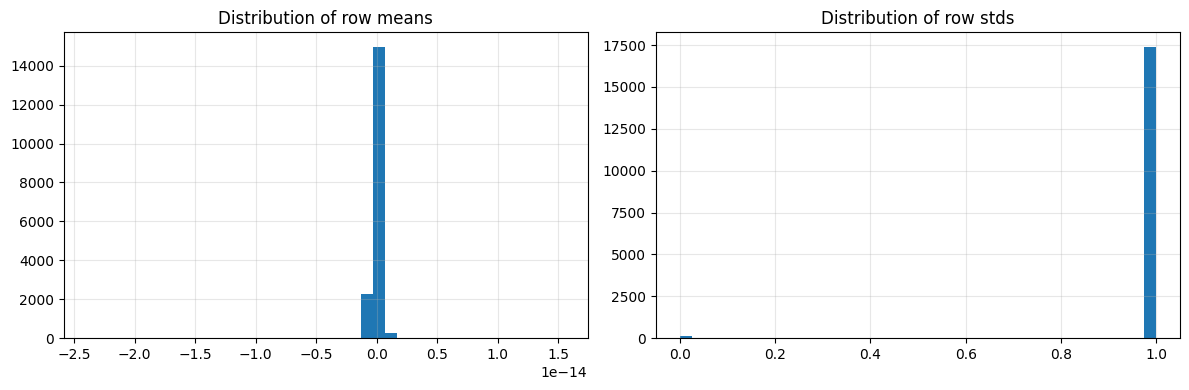

In [4]:
row_means = X_df.mean(axis=1)
row_stds = X_df.std(axis=1, ddof=0)

print("Average of row means:", row_means.mean())
print("Average of row stds :", row_stds.mean())

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(row_means, bins=40)
plt.title("Distribution of row means")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(row_stds, bins=40)
plt.title("Distribution of row stds")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Optional z-normalisation helper

If you loaded the raw dataset instead of the z-normalised one, run the next cell.
If you already loaded `sample_23_znorm.parquet`, you can still run it safely; it should change very little.


In [5]:
def z_normalise_row(row, eps=1e-8):
    arr = row.to_numpy(dtype=float)
    mean = arr.mean()
    std = arr.std()
    if std < eps:
        return np.zeros_like(arr)
    return (arr - mean) / std

X_z = X_df.apply(z_normalise_row, axis=1, result_type="expand")
X_z.columns = value_cols
X_z = X_z.to_numpy(dtype=float)

print("Shape of z-normalised matrix:", X_z.shape)


Shape of z-normalised matrix: (17547, 365)


## 5. Visual inspection of some households

This helps you see whether local motifs seem plausible.


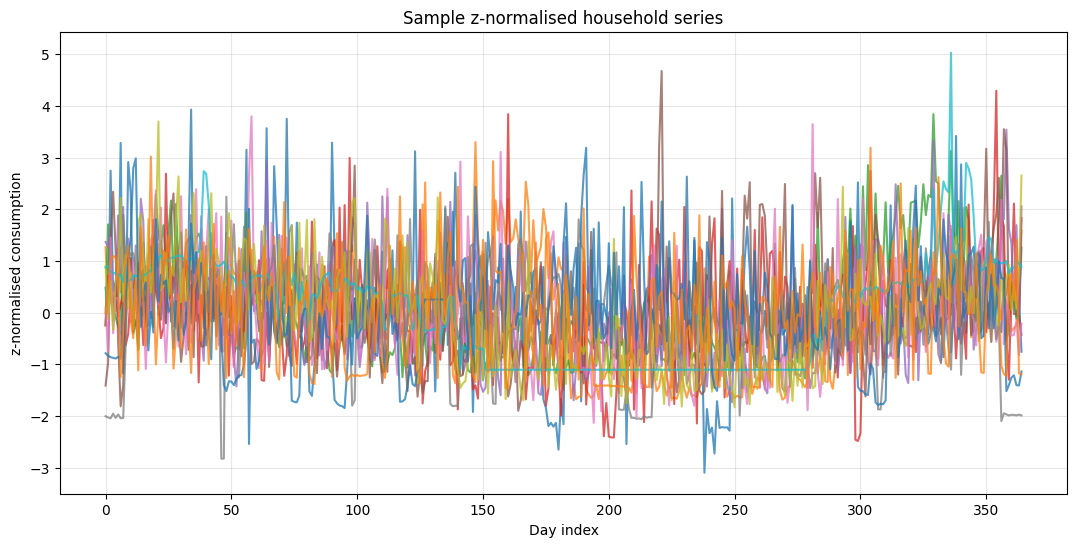

In [6]:
sample_idx = rng.choice(len(X_z), size=min(12, len(X_z)), replace=False)

plt.figure(figsize=(13, 6))
for idx in sample_idx:
    plt.plot(X_z[idx], alpha=0.75, label=str(ids.iloc[idx]))
plt.title("Sample z-normalised household series")
plt.xlabel("Day index")
plt.ylabel("z-normalised consumption")
plt.grid(True, alpha=0.3)
plt.show()


## 6. Shapelet helper functions

We will:
- sample candidate subsequences from the z-normalised household series
- score them in an unsupervised way using variation of the distance profile
- prune redundant candidates
- keep a small diverse set of shapelets


In [7]:
def sliding_windows_1d(series, length):
    series = np.asarray(series, dtype=float)
    return np.lib.stride_tricks.sliding_window_view(series, window_shape=length)

def z_norm_subsequence(subseq, eps=1e-8):
    subseq = np.asarray(subseq, dtype=float)
    std = subseq.std()
    if std < eps:
        return np.zeros_like(subseq)
    return (subseq - subseq.mean()) / std

def min_dist_to_shapelet(series, shapelet):
    L = len(shapelet)
    windows = sliding_windows_1d(series, L)
    means = windows.mean(axis=1, keepdims=True)
    stds = windows.std(axis=1, keepdims=True)
    stds = np.where(stds < 1e-8, 1.0, stds)
    windows_z = (windows - means) / stds
    dists = np.sqrt(((windows_z - shapelet) ** 2).sum(axis=1))
    return float(dists.min())

def distance_profile_all_series(X_series, shapelet):
    return np.array([min_dist_to_shapelet(row, shapelet) for row in X_series], dtype=float)

def sample_candidate_shapelets(X_series, lengths, candidates_per_length, rng):
    n_series, n_steps = X_series.shape
    candidates = []
    for L in lengths:
        for _ in range(candidates_per_length):
            i = rng.integers(0, n_series)
            start = rng.integers(0, n_steps - L + 1)
            values = z_norm_subsequence(X_series[i, start:start + L])
            candidates.append({
                "length": int(L),
                "series_index": int(i),
                "start": int(start),
                "values": values
            })
    return candidates

def score_candidate_unsupervised(X_series, candidate_values):
    profile = distance_profile_all_series(X_series, candidate_values)
    return float(np.var(profile)), profile

def corr_similarity(a, b):
    if len(a) != len(b):
        return 0.0
    if np.std(a) < 1e-8 or np.std(b) < 1e-8:
        return float(np.allclose(a, b))
    return float(np.corrcoef(a, b)[0, 1])

def select_diverse_shapelets(scored_candidates, top_per_length=5, max_total=15, similarity_threshold=0.92):
    selected = []
    counts_by_length = {}
    scored_candidates = sorted(scored_candidates, key=lambda d: d["score"], reverse=True)

    for cand in scored_candidates:
        L = cand["length"]
        if counts_by_length.get(L, 0) >= top_per_length:
            continue

        too_similar = False
        for kept in selected:
            if kept["length"] == L and corr_similarity(cand["values"], kept["values"]) >= similarity_threshold:
                too_similar = True
                break

        if not too_similar:
            selected.append(cand)
            counts_by_length[L] = counts_by_length.get(L, 0) + 1

        if len(selected) >= max_total:
            break
    return selected


## 7. Sample and score candidate shapelets


In [8]:
t0 = time.time()
candidates = sample_candidate_shapelets(
    X_series=X_z,
    lengths=SHAPELET_LENGTHS,
    candidates_per_length=CANDIDATES_PER_LENGTH,
    rng=rng
)

print("Number of sampled candidates:", len(candidates))

# Parallelize scoring across all CPU cores
def score_one_candidate(cand, X_series):
    score, profile = score_candidate_unsupervised(X_series, cand["values"])
    cand2 = dict(cand)
    cand2["score"] = score
    cand2["profile"] = profile
    return cand2

scored = Parallel(n_jobs=-1, verbose=1)(
    delayed(score_one_candidate)(cand, X_z) for cand in candidates
)

t_score = time.time() - t0
print(f"✓ Candidate scoring completed in {t_score:.1f}s")
shapelets = select_diverse_shapelets(
    scored_candidates=scored,
    top_per_length=TOP_SHAPELETS_PER_LENGTH,
    max_total=MAX_TOTAL_SHAPELETS,
    similarity_threshold=SIMILARITY_THRESHOLD
)

shapelet_summary = pd.DataFrame({
    "shapelet_id": [f"sh_{i:02d}" for i in range(len(shapelets))],
    "length": [s["length"] for s in shapelets],
    "score": [s["score"] for s in shapelets],
    "source_id": [ids.iloc[s["series_index"]] for s in shapelets],
    "source_series_index": [s["series_index"] for s in shapelets],
    "start": [s["start"] for s in shapelets]
})

display(shapelet_summary)
shapelet_summary.to_csv(OUTPUT_DIR / "shapelet_summary.csv", index=False)


Number of sampled candidates: 320


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   27.3s


✓ Candidate scoring completed in 57.6s


[Parallel(n_jobs=-1)]: Done 320 out of 320 | elapsed:   57.5s finished


,shapelet_id,length,score,source_id,source_series_index,start
0,sh_00,60,2.535077,179226,10180,241
1,sh_01,60,1.559508,278578,16015,264
2,sh_02,60,1.538163,209825,11995,176
3,sh_03,30,1.456064,13473,798,103
4,sh_04,60,1.165128,80961,4613,17
5,sh_05,60,1.133258,6860,418,246
6,sh_06,30,0.979236,270788,15550,217
7,sh_07,30,0.950875,224270,12828,216
8,sh_08,30,0.755547,10770,636,44
9,sh_09,14,0.648208,236479,13522,76


## 8. Visualise the selected shapelets

This is one of the most useful cells for your report, because it lets you talk about the actual local motifs you found.


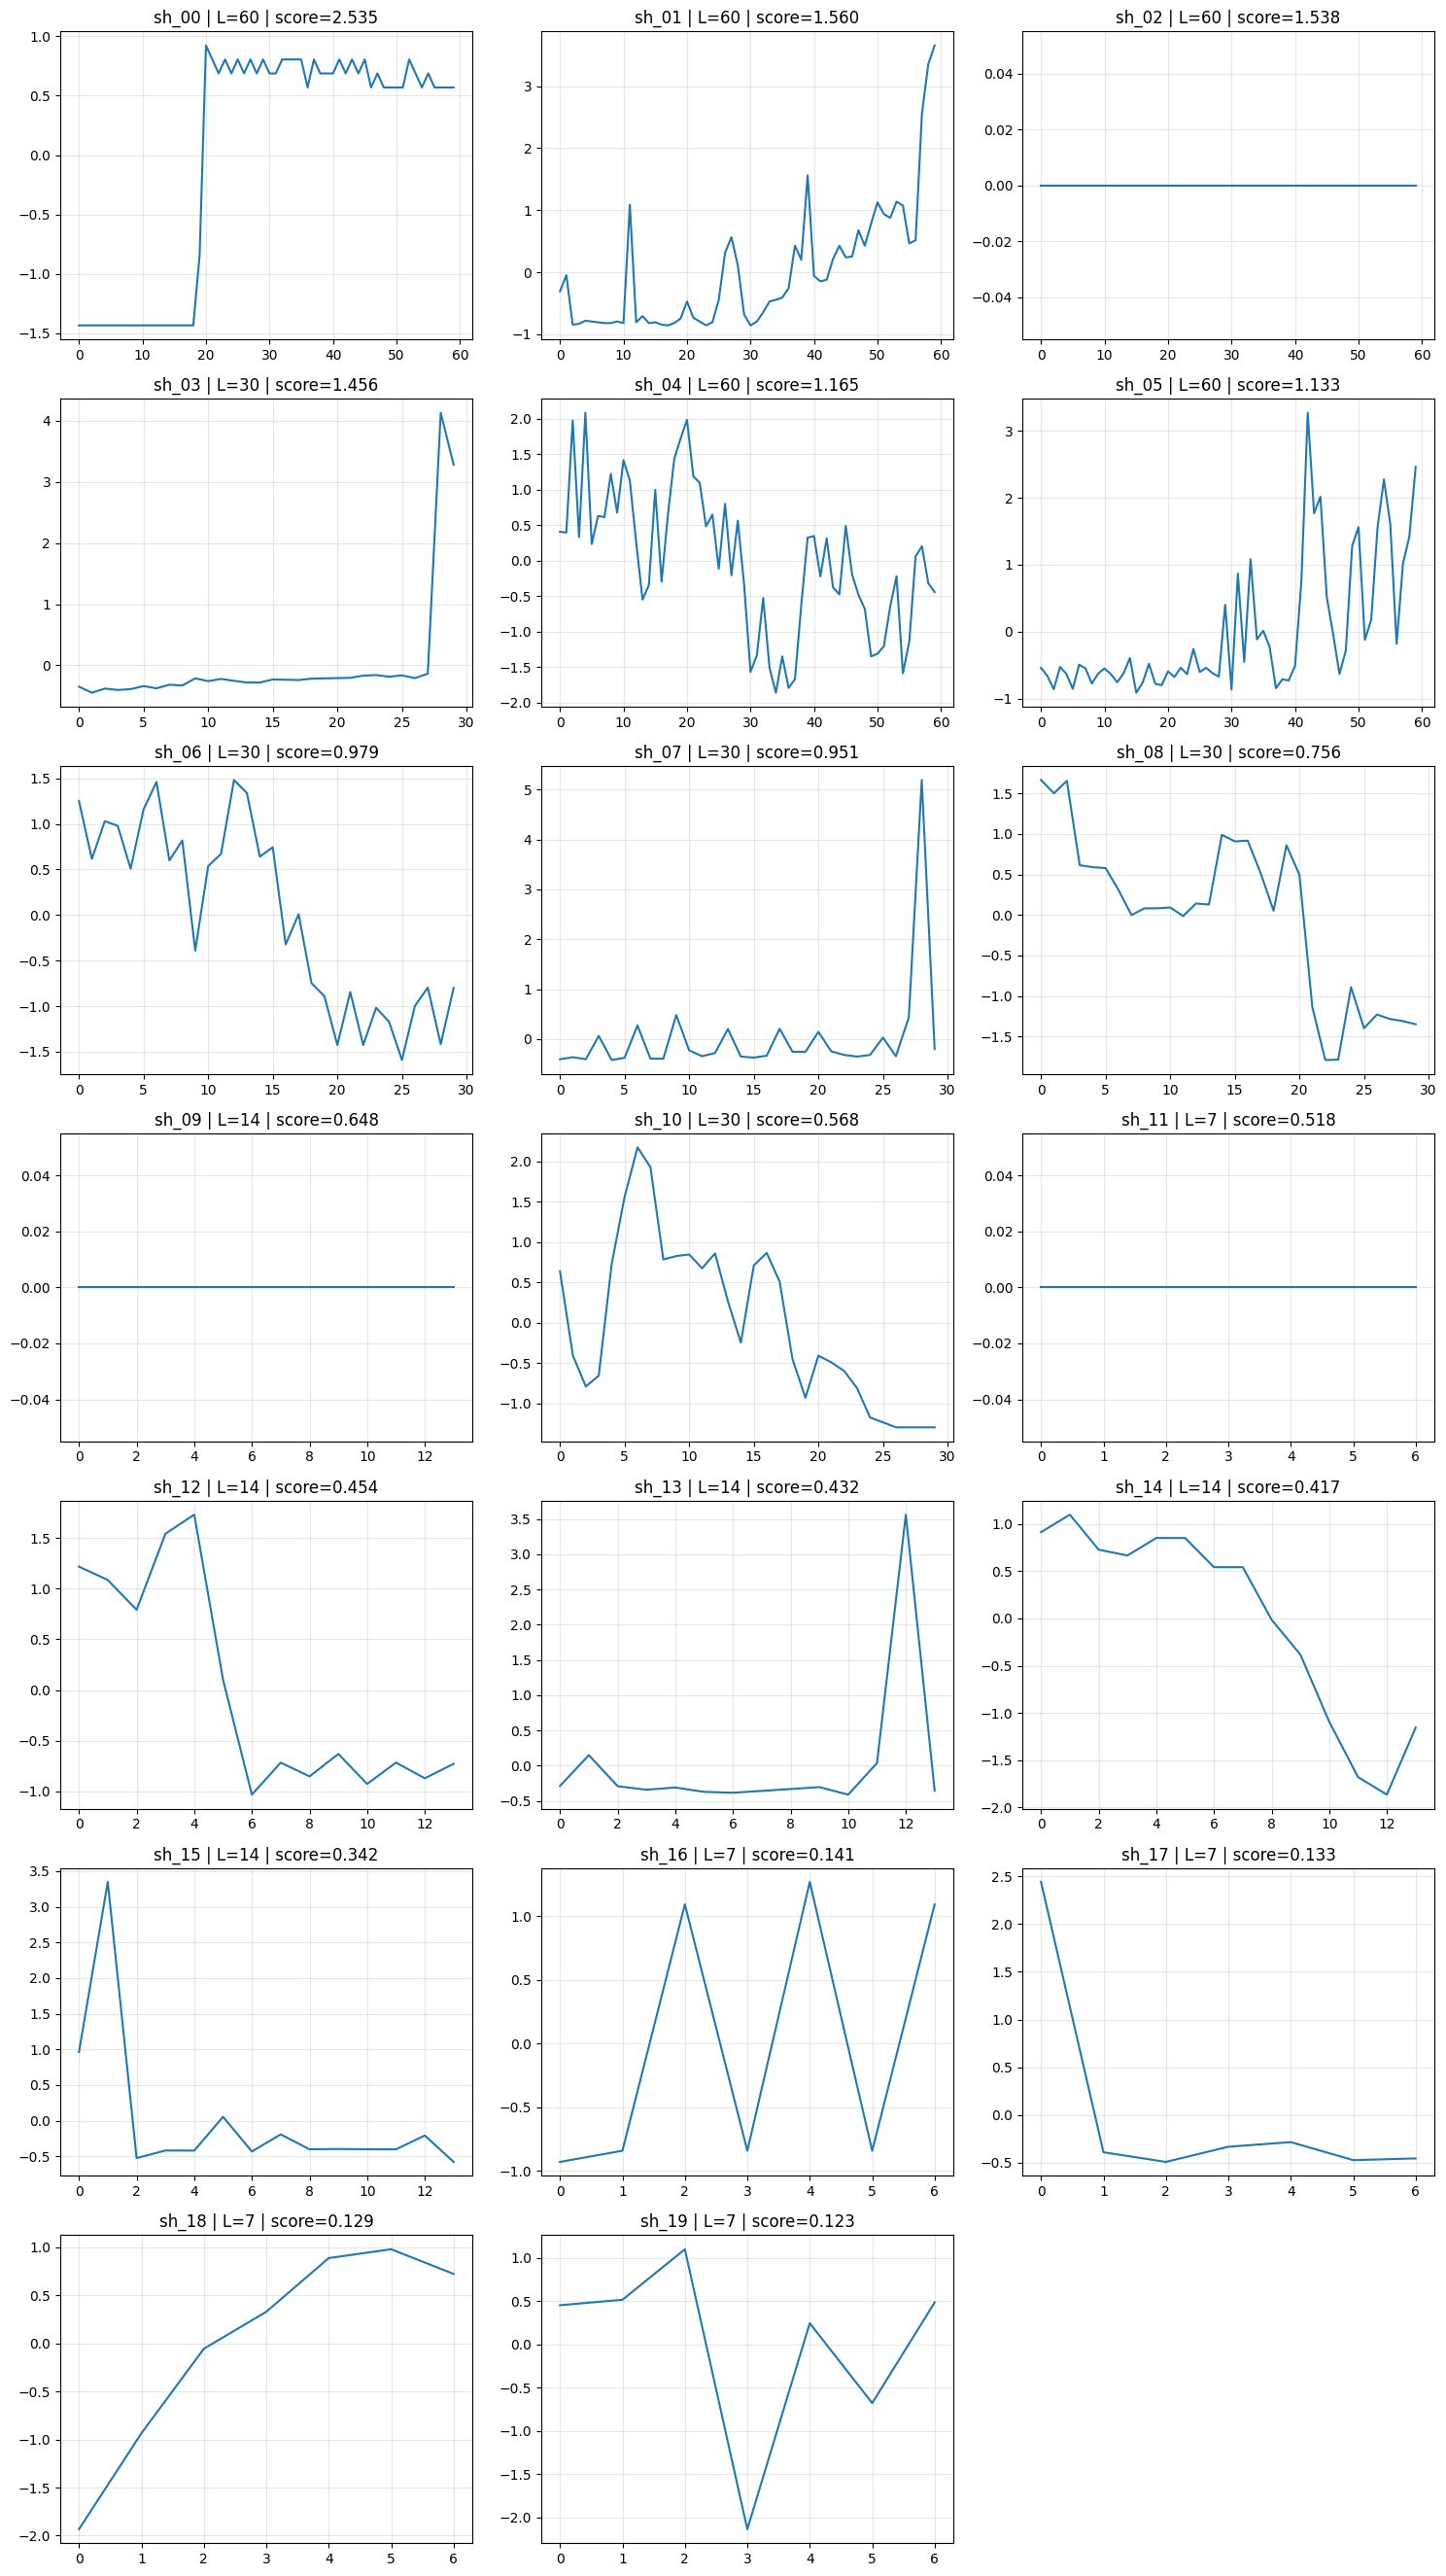

In [9]:
n = len(shapelets)
ncols = 3
nrows = math.ceil(max(n, 1) / ncols)

plt.figure(figsize=(15, 3.8 * nrows))
for i, sh in enumerate(shapelets, start=1):
    plt.subplot(nrows, ncols, i)
    plt.plot(sh["values"])
    plt.title(f"sh_{i-1:02d} | L={sh['length']} | score={sh['score']:.3f}")
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Show where a shapelet came from

Pick one of the selected shapelets and plot it inside the source series.
This is helpful for interpretation.


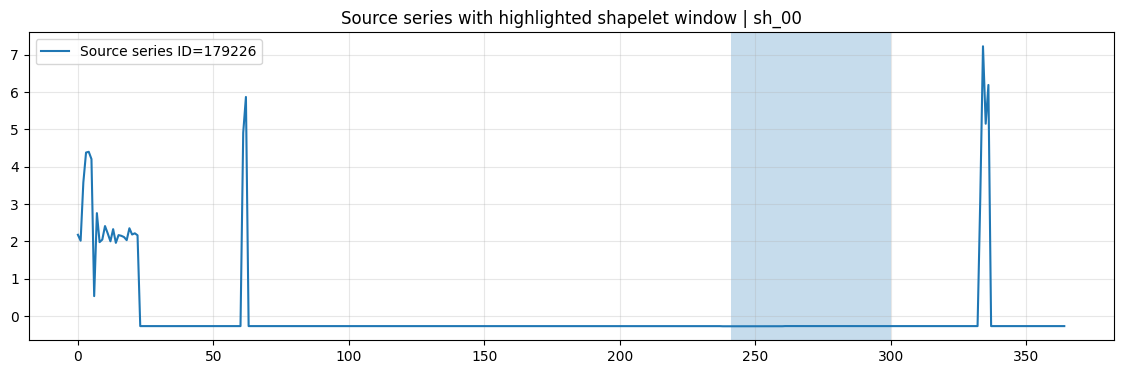

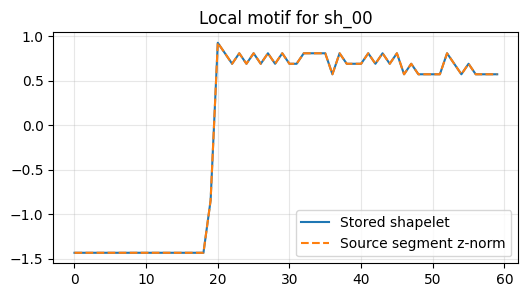

In [10]:
SHAPELET_TO_INSPECT = 0

sh = shapelets[SHAPELET_TO_INSPECT]
series_idx = sh["series_index"]
start = sh["start"]
L = sh["length"]

series = X_z[series_idx]
segment = series[start:start+L]

plt.figure(figsize=(14, 4))
plt.plot(series, label=f"Source series ID={ids.iloc[series_idx]}")
plt.axvspan(start, start + L - 1, alpha=0.25)
plt.title(f"Source series with highlighted shapelet window | sh_{SHAPELET_TO_INSPECT:02d}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(6, 3))
plt.plot(sh["values"], label="Stored shapelet")
plt.plot(z_norm_subsequence(segment), linestyle="--", label="Source segment z-norm")
plt.title(f"Local motif for sh_{SHAPELET_TO_INSPECT:02d}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 10. Shapelet transform

For each household and each selected shapelet, compute the minimum sliding-window distance.
This gives a new household representation:
- one row per household
- one column per shapelet

⏱️ **This also runs in parallel** and should complete in <1 minute for 14K series.


In [11]:
feature_names = [f"shapelet_dist_{i:02d}_L{sh['length']}" for i, sh in enumerate(shapelets)]

t0 = time.time()
# Parallelize distance profile computation
dist_profiles = Parallel(n_jobs=-1, verbose=1)(
    delayed(distance_profile_all_series)(X_z, sh["values"]) for sh in shapelets
)

X_shapelet = np.column_stack(dist_profiles)

t_transform = time.time() - t0
print(f"✓ Shapelet transform completed in {t_transform:.1f}s")

shapelet_features_df = pd.DataFrame(X_shapelet, columns=feature_names)
shapelet_features_df.insert(0, "ID", ids.values)

display(shapelet_features_df.head())
shapelet_features_df.to_csv(OUTPUT_DIR / "shapelet_features.csv", index=False)
shapelet_features_df.to_parquet(OUTPUT_DIR / "shapelet_features.parquet", index=False)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


✓ Shapelet transform completed in 4.5s


[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:    4.4s finished


,ID,shapelet_dist_00_L60,shapelet_dist_01_L60,shapelet_dist_02_L60,shapelet_dist_03_L30,shapelet_dist_04_L60,shapelet_dist_05_L60,shapelet_dist_06_L30,shapelet_dist_07_L30,shapelet_dist_08_L30,...,shapelet_dist_10_L30,shapelet_dist_11_L7,shapelet_dist_12_L14,shapelet_dist_13_L14,shapelet_dist_14_L14,shapelet_dist_15_L14,shapelet_dist_16_L7,shapelet_dist_17_L7,shapelet_dist_18_L7,shapelet_dist_19_L7
0,22,6.929794,6.351589,7.745967,4.250408,7.176821,6.737780,2.735922,5.320270,3.922210,...,3.145308,2.645751,1.583744,2.438938,1.510127,2.462247,1.100626,0.324710,0.987425,1.512707
1,42,5.681148,4.202240,7.745967,0.417846,6.961685,5.890246,3.202861,3.371551,3.897018,...,4.326213,2.645751,1.529404,1.288528,1.528673,1.469887,0.846892,0.171080,0.904218,1.390733
2,56,7.169017,6.160748,7.745967,2.707806,6.280869,6.687506,2.539171,1.613350,3.202221,...,3.350629,2.645751,0.702345,0.747249,1.596529,0.996241,1.439951,0.195013,1.420683,1.798794
3,58,7.068253,6.160862,7.745967,3.528181,7.382807,6.686293,3.826556,3.804479,4.509428,...,4.461795,2.645751,2.190994,2.041905,2.375977,1.251135,1.555010,0.430333,0.987952,1.293519
4,64,5.424710,7.643887,7.745967,5.538089,8.216635,7.967182,3.216821,4.546296,3.834625,...,4.237930,2.645751,0.826899,1.819944,1.429721,1.407642,0.794343,0.417286,0.622129,0.807072


## 11. Visualise the shapelet feature distributions

This is useful for seeing whether the shapelets create separation between households.


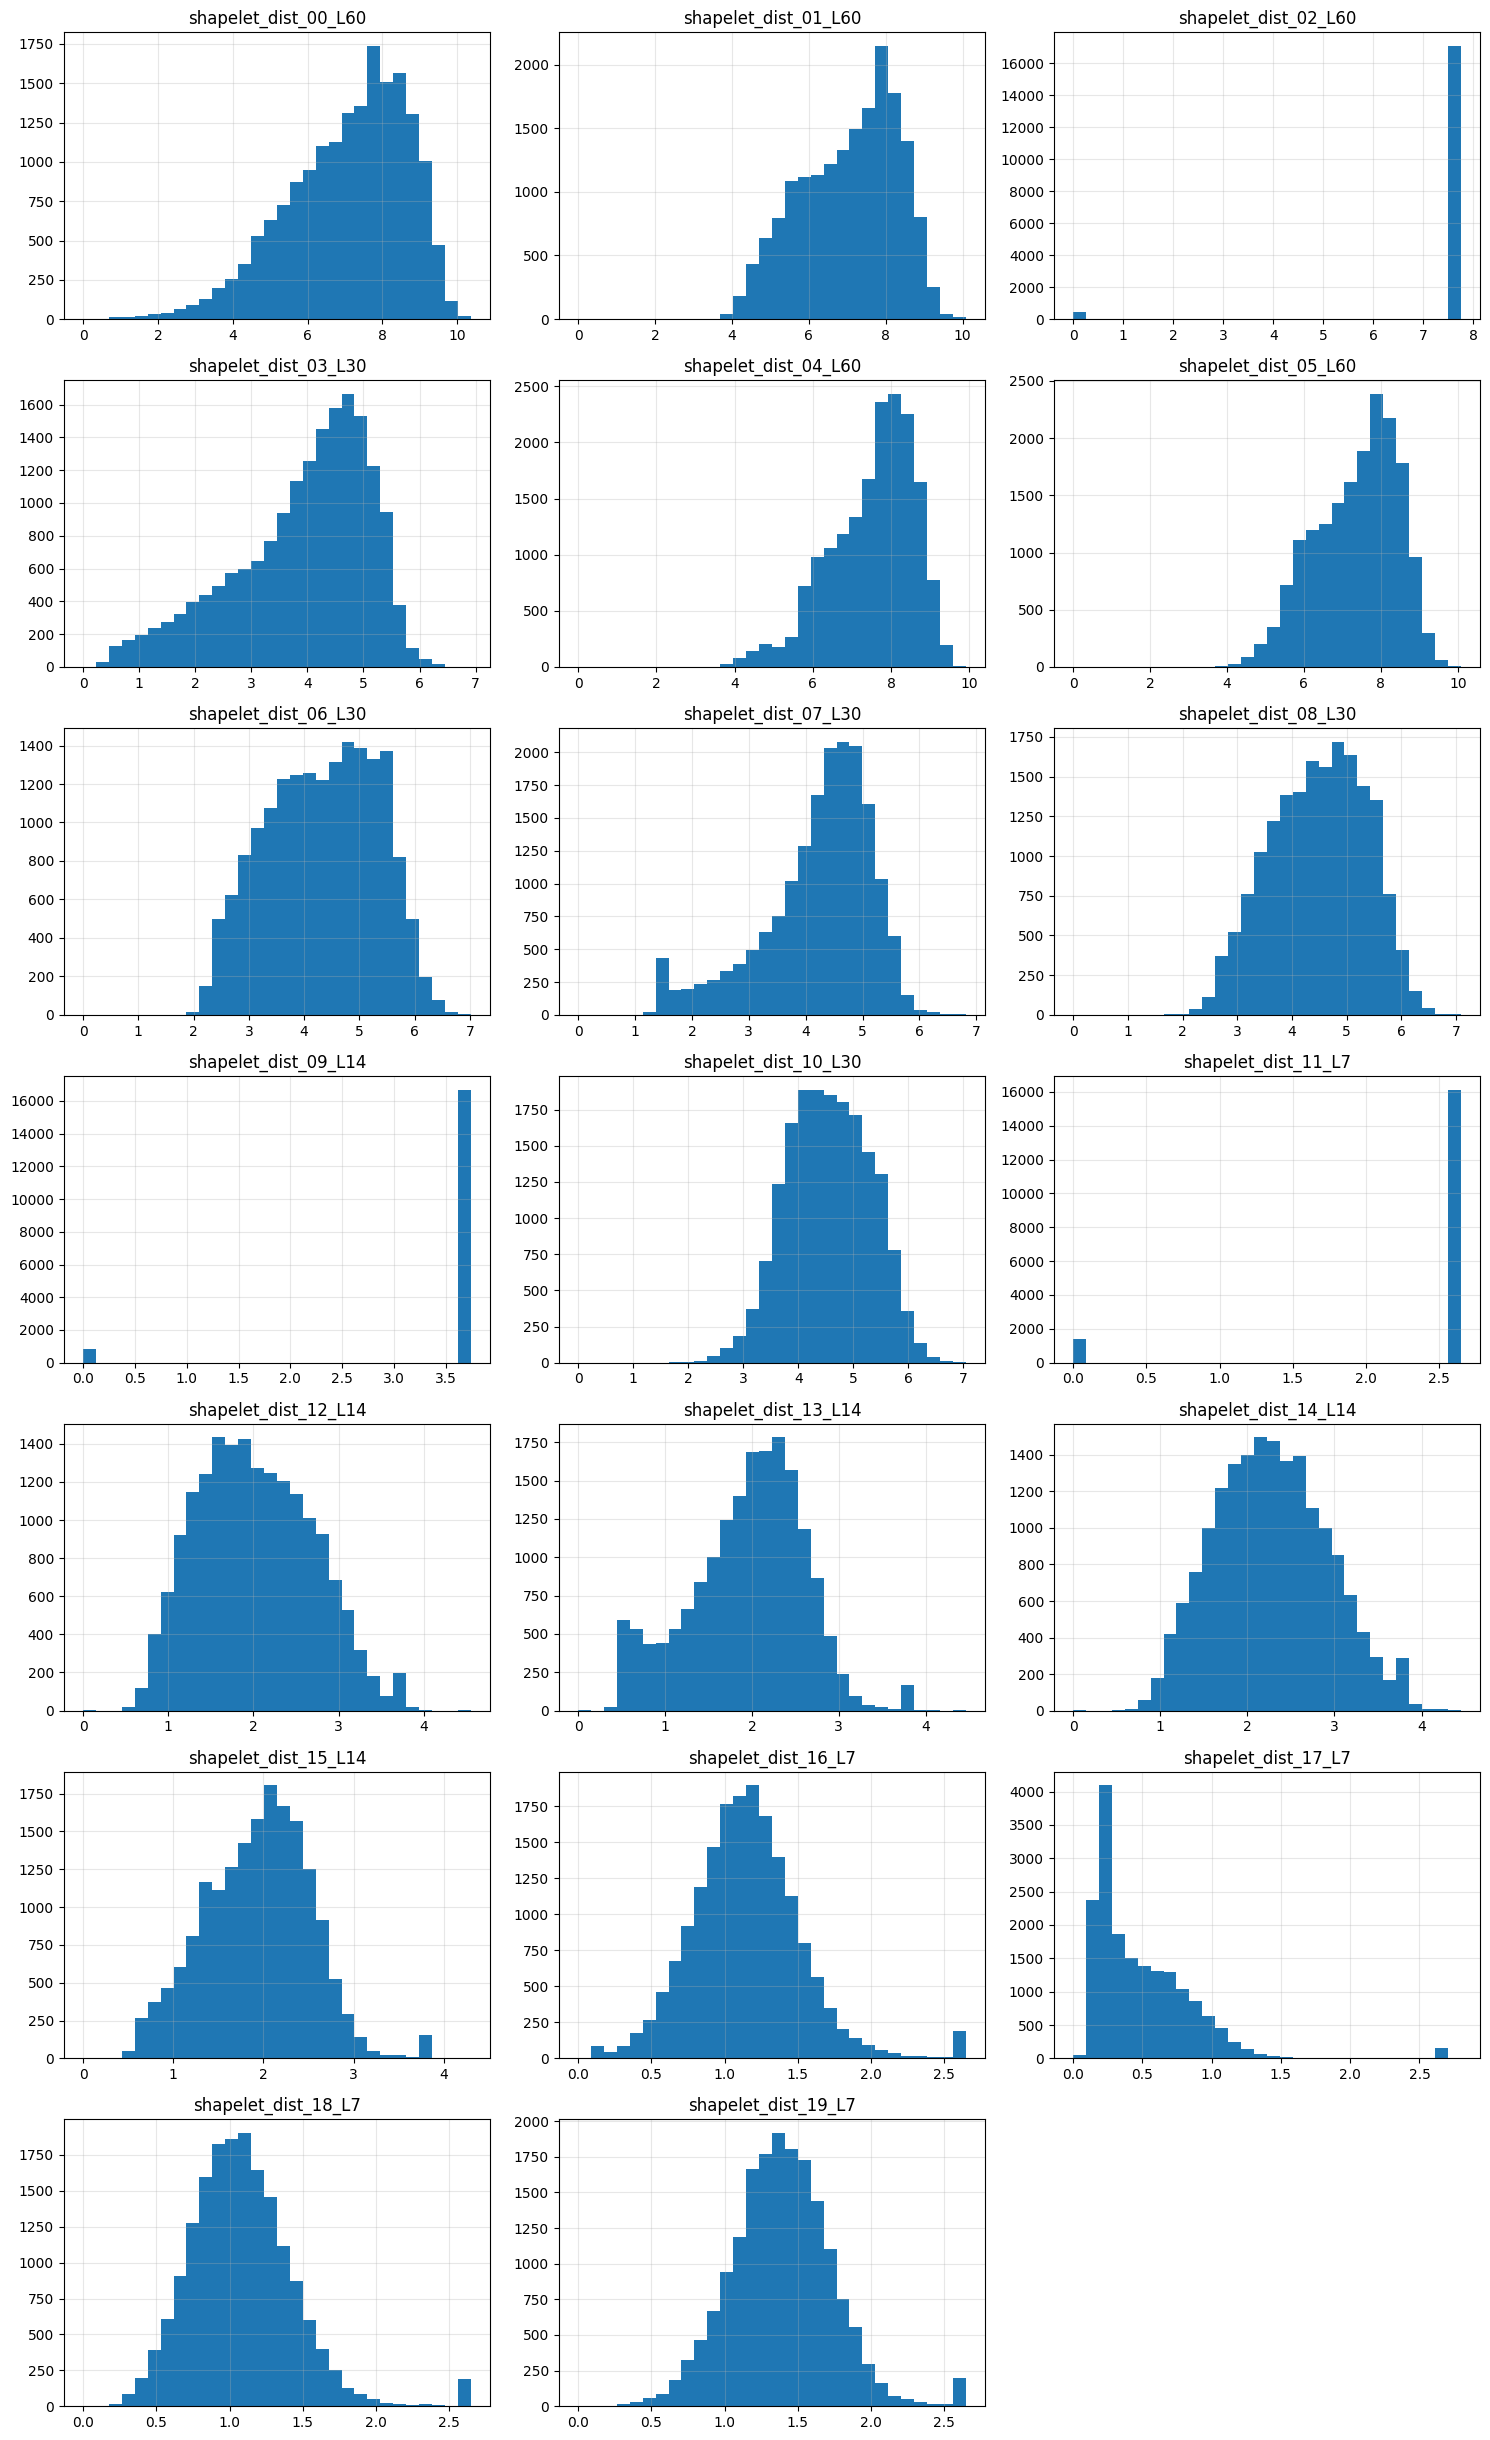

In [12]:
n = len(feature_names)
ncols = 3
nrows = math.ceil(max(n, 1) / ncols)

plt.figure(figsize=(15, 3.5 * nrows))
for i, col in enumerate(feature_names, start=1):
    plt.subplot(nrows, ncols, i)
    plt.hist(shapelet_features_df[col], bins=30)
    plt.title(col)
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 12. Standardise shapelet features and search for a good k

⏱️ **This now runs faster** with reduced n_init (20→5) and fewer k values (2-9 → 2-7).
Still robust for 14K samples but typically completes in 1-2 minutes total.


✓ K-search completed in 9.3s


,k,silhouette,davies_bouldin,calinski_harabasz
0,2,0.233735,1.591225,5777.482378
1,3,0.244154,1.396246,4608.115619
2,4,0.149814,1.745930,3942.502040
3,5,0.144361,1.779124,3424.442155
4,6,0.156350,1.564263,3421.968532


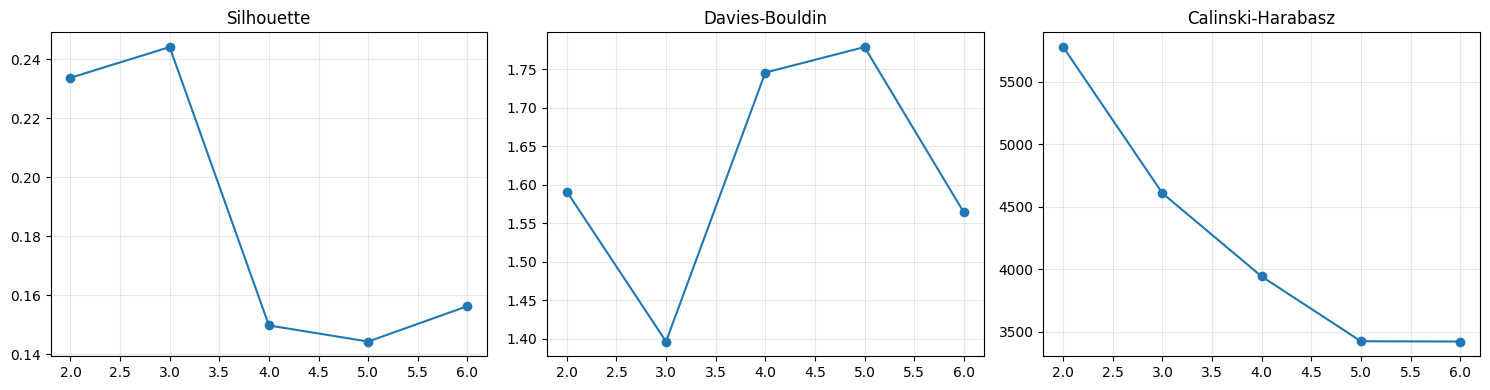

In [13]:
scaler = StandardScaler()
t0 = time.time()
X_shapelet_scaled = scaler.fit_transform(X_shapelet)

rows = []
for k in K_RANGE:
    model = AgglomerativeClustering(n_clusters=k) if FINAL_CLUSTERER == "agglo" else KMeans(n_clusters=k, random_state=SEED, n_init=5)
    labels = model.fit_predict(X_shapelet_scaled)

    rows.append({
        "k": k,
        "silhouette": silhouette_score(X_shapelet_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_shapelet_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_shapelet_scaled, labels)
    })

k_metrics = pd.DataFrame(rows)
t_k_search = time.time() - t0
print(f"✓ K-search completed in {t_k_search:.1f}s")

display(k_metrics)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(k_metrics["k"], k_metrics["silhouette"], marker="o")
plt.title("Silhouette")
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(k_metrics["k"], k_metrics["davies_bouldin"], marker="o")
plt.title("Davies-Bouldin")
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(k_metrics["k"], k_metrics["calinski_harabasz"], marker="o")
plt.title("Calinski-Harabasz")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 13. Choose k and cluster in shapelet space

In [14]:
CHOSEN_K = 4

if FINAL_CLUSTERER == "agglo":
    clusterer = AgglomerativeClustering(n_clusters=CHOSEN_K)
else:
    clusterer = KMeans(n_clusters=CHOSEN_K, random_state=SEED, n_init=5)

shapelet_labels = clusterer.fit_predict(X_shapelet_scaled)

cluster_labels_df = pd.DataFrame({
    "ID": ids.values,
    "shapelet_cluster": shapelet_labels
})

display(cluster_labels_df.head())
display(cluster_labels_df["shapelet_cluster"].value_counts().sort_index())

cluster_labels_df.to_csv(OUTPUT_DIR / "shapelet_cluster_labels.csv", index=False)


,ID,shapelet_cluster
0,22,3
1,42,0
2,56,0
3,58,3
4,64,3


shapelet_cluster
0    4519
1    5750
2     512
3    6766
Name: count, dtype: int64

## 14. PCA visualisation of households in shapelet space

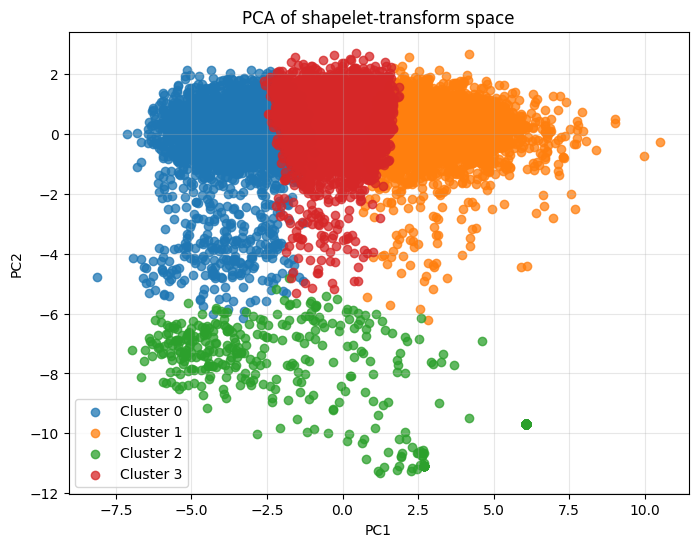

Explained variance ratio: [0.3631301  0.14938727]


In [15]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_shapelet_scaled)

viz_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": shapelet_labels.astype(str),
    "ID": ids.values
})

plt.figure(figsize=(8, 6))
for cid in sorted(viz_df["cluster"].unique(), key=int):
    part = viz_df[viz_df["cluster"] == cid]
    plt.scatter(part["PC1"], part["PC2"], alpha=0.75, label=f"Cluster {cid}")
plt.title("PCA of shapelet-transform space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


## 15. Visualise representative households by cluster

This helps you see whether clusters found in shapelet space correspond to understandable time-series behaviours.


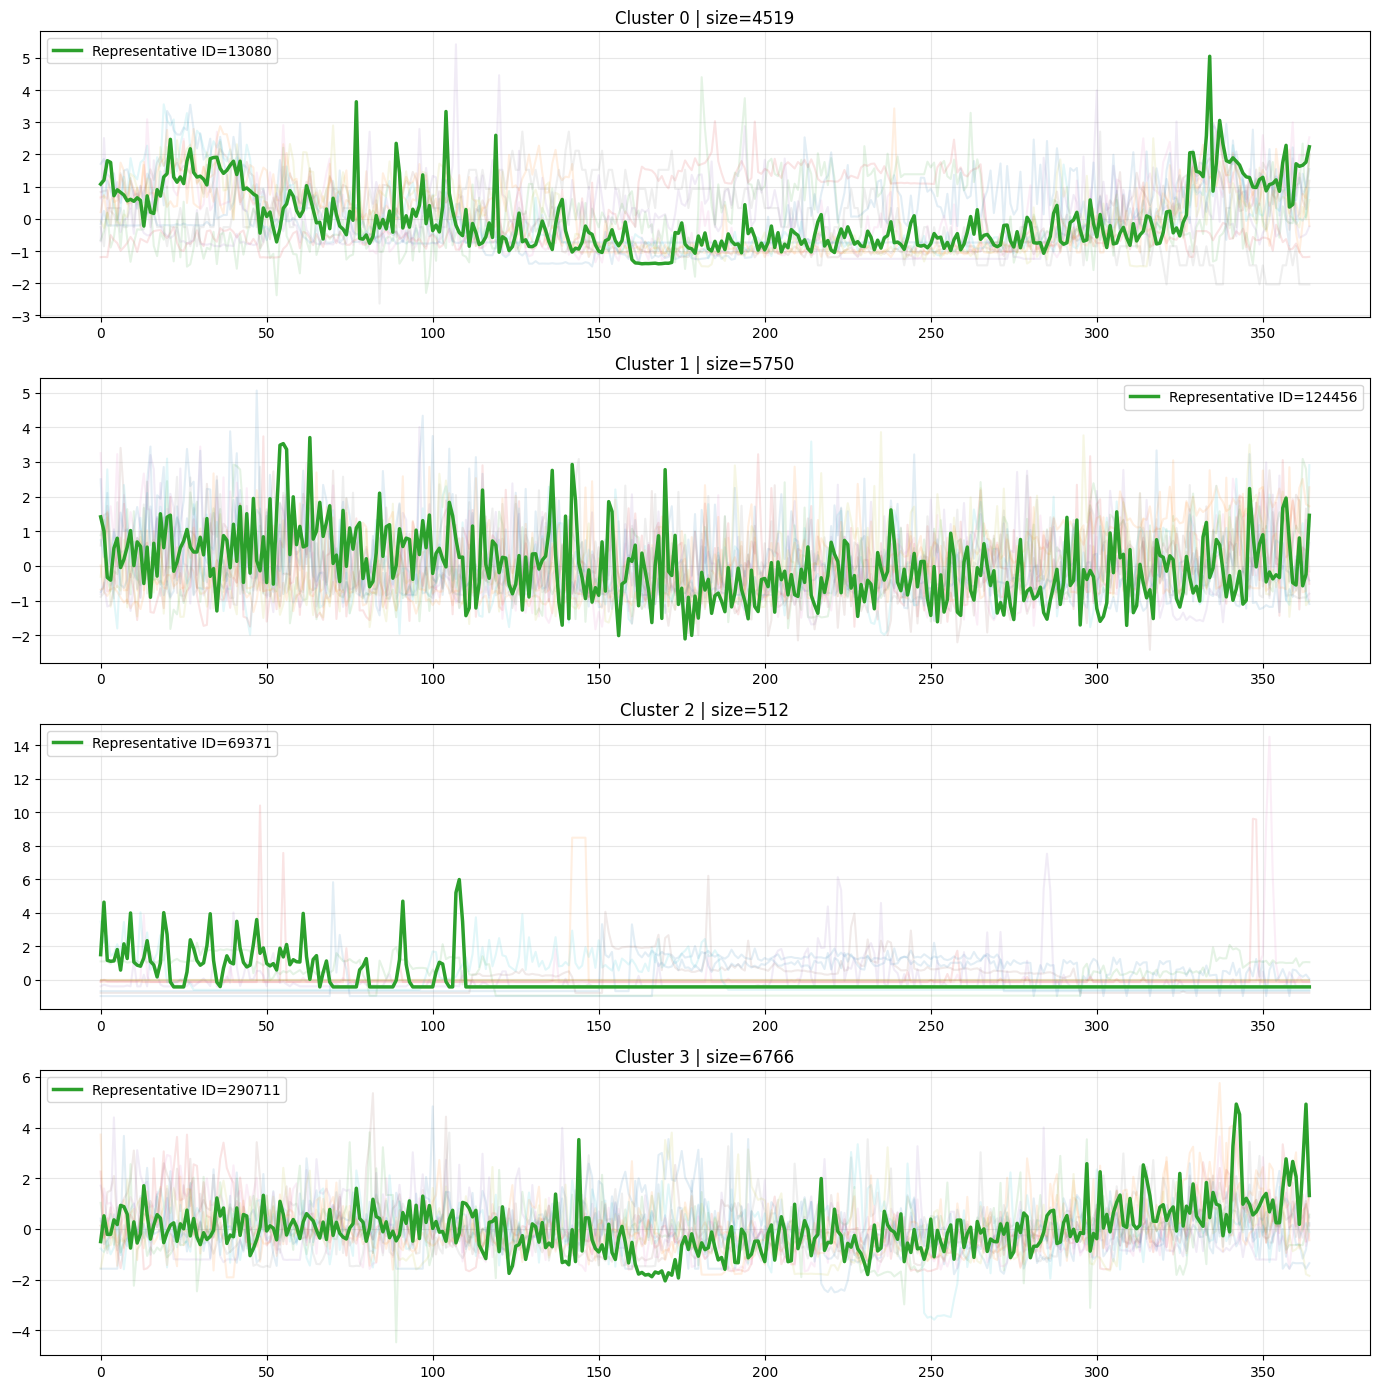

,cluster,ID,row_index
0,0,13080,773
1,1,124456,7139
2,2,69371,3946
3,3,290711,16706


In [16]:
def representative_index_for_cluster(X_feat, labels, cluster_id):
    idx = np.where(labels == cluster_id)[0]
    centroid = X_feat[idx].mean(axis=0, keepdims=True)
    distances = cdist(X_feat[idx], centroid).ravel()
    return idx[np.argmin(distances)]

cluster_ids = sorted(np.unique(shapelet_labels))
representatives = []

plt.figure(figsize=(14, 3.5 * len(cluster_ids)))
for plot_idx, cid in enumerate(cluster_ids, start=1):
    rep_idx = representative_index_for_cluster(X_shapelet_scaled, shapelet_labels, cid)
    representatives.append({"cluster": int(cid), "ID": ids.iloc[rep_idx], "row_index": int(rep_idx)})

    member_idx = np.where(shapelet_labels == cid)[0]
    subset = member_idx[:min(12, len(member_idx))]

    plt.subplot(len(cluster_ids), 1, plot_idx)
    for i in subset:
        plt.plot(X_z[i], alpha=0.12)
    plt.plot(X_z[rep_idx], linewidth=2.5, label=f"Representative ID={ids.iloc[rep_idx]}")
    plt.title(f"Cluster {cid} | size={len(member_idx)}")
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

representatives_df = pd.DataFrame(representatives)
display(representatives_df)
representatives_df.to_csv(OUTPUT_DIR / "shapelet_cluster_representatives.csv", index=False)


## 16. Which shapelets matter most for each cluster?

This is very useful for interpretation:
- low distance to a shapelet means the cluster tends to contain that motif
- high distance means the motif is less present


In [17]:
cluster_shapelet_means = (
    pd.DataFrame(X_shapelet_scaled, columns=feature_names)
    .assign(cluster=shapelet_labels)
    .groupby("cluster")
    .mean()
)

display(cluster_shapelet_means)

for cid in cluster_shapelet_means.index:
    print(f"\nCluster {cid}: strongest matching shapelets")
    print(cluster_shapelet_means.loc[cid].sort_values().head(5))


,shapelet_dist_00_L60,shapelet_dist_01_L60,shapelet_dist_02_L60,shapelet_dist_03_L30,shapelet_dist_04_L60,shapelet_dist_05_L60,shapelet_dist_06_L30,shapelet_dist_07_L30,shapelet_dist_08_L30,shapelet_dist_09_L14,shapelet_dist_10_L30,shapelet_dist_11_L7,shapelet_dist_12_L14,shapelet_dist_13_L14,shapelet_dist_14_L14,shapelet_dist_15_L14,shapelet_dist_16_L7,shapelet_dist_17_L7,shapelet_dist_18_L7,shapelet_dist_19_L7
cluster,,,,,,,,,,,,,,,,,,,,
0,-1.016688,-1.155209,0.164442,-0.966706,-1.170956,-1.160327,-1.020016,-0.569819,-0.980072,-0.011378,-1.006940,-0.065954,-0.809459,-0.363973,-0.921295,-0.416516,0.073597,-0.267460,-0.586931,-0.127774
1,0.845979,0.807890,0.164442,0.612630,0.831257,0.805861,0.989397,0.369888,0.936691,0.195471,0.976451,0.191758,0.897926,0.270816,0.810258,0.460398,-0.150499,0.342973,0.414523,0.003333
2,-0.261387,-0.304372,-5.471239,-0.645223,-0.364852,-0.375440,0.079986,-0.728412,0.058609,-4.421181,0.143756,-3.379091,0.564383,0.157194,0.660612,0.307488,2.088551,1.176725,1.839153,1.917735
3,-0.020121,0.108020,0.164442,0.173851,0.103255,0.118541,-0.165612,0.121357,-0.145881,0.176042,-0.168170,0.136791,-0.265163,0.001052,-0.123246,-0.136342,-0.079301,-0.201881,-0.099440,-0.062612



Cluster 0: strongest matching shapelets
shapelet_dist_04_L60   -1.170956
shapelet_dist_05_L60   -1.160327
shapelet_dist_01_L60   -1.155209
shapelet_dist_06_L30   -1.020016
shapelet_dist_00_L60   -1.016688
Name: 0, dtype: float64

Cluster 1: strongest matching shapelets
shapelet_dist_16_L7    -0.150499
shapelet_dist_19_L7     0.003333
shapelet_dist_02_L60    0.164442
shapelet_dist_11_L7     0.191758
shapelet_dist_09_L14    0.195471
Name: 1, dtype: float64

Cluster 2: strongest matching shapelets
shapelet_dist_02_L60   -5.471239
shapelet_dist_09_L14   -4.421181
shapelet_dist_11_L7    -3.379091
shapelet_dist_07_L30   -0.728412
shapelet_dist_03_L30   -0.645223
Name: 2, dtype: float64

Cluster 3: strongest matching shapelets
shapelet_dist_12_L14   -0.265163
shapelet_dist_17_L7    -0.201881
shapelet_dist_10_L30   -0.168170
shapelet_dist_06_L30   -0.165612
shapelet_dist_08_L30   -0.145881
Name: 3, dtype: float64


## 17. Optional: augment with engineered feature table

This is one of the most practical uses of shapelets in our project:
add local motif-distance features to the existing engineered features instead of replacing them.


In [18]:
if FEATURE_TABLE_PATH.exists():
    feat_df = load_table(FEATURE_TABLE_PATH)
    augmented = feat_df.merge(shapelet_features_df, on="ID", how="inner")
    augmented = augmented.merge(cluster_labels_df, on="ID", how="left")

    print("Original feature table shape :", feat_df.shape)
    print("Augmented feature table shape:", augmented.shape)
    display(augmented.head())

    augmented.to_csv(OUTPUT_DIR / "engineered_features_plus_shapelets.csv", index=False)
    augmented.to_parquet(OUTPUT_DIR / "engineered_features_plus_shapelets.parquet", index=False)
else:
    print(f"Feature table not found: {FEATURE_TABLE_PATH}")


Original feature table shape : (17393, 62)
Augmented feature table shape: (17393, 83)


,ID,mean,median,std,cv,p90_p10_ratio,max_median_ratio,above_p90_fraction,trend_slope,acf1,...,shapelet_dist_11_L7,shapelet_dist_12_L14,shapelet_dist_13_L14,shapelet_dist_14_L14,shapelet_dist_15_L14,shapelet_dist_16_L7,shapelet_dist_17_L7,shapelet_dist_18_L7,shapelet_dist_19_L7,shapelet_cluster
0,22,2.553960,2.520274,1.604054,0.288979,1.214175,1.184612,0.096555,-0.009505,0.589803,...,2.645751,1.583744,2.438938,1.510127,2.462247,1.100626,0.324710,0.987425,1.512707,3
1,42,2.711698,1.528228,2.993501,0.853853,5.183883,3.157271,0.096555,-0.022695,0.907323,...,2.645751,1.529404,1.288528,1.528673,1.469887,0.846892,0.171080,0.904218,1.390733,0
2,56,1.888519,1.907912,1.826231,0.656922,4.561882,1.627808,0.096555,-0.016571,0.783508,...,2.645751,0.702345,0.747249,1.596529,0.996241,1.439951,0.195013,1.420683,1.798794,0
3,58,2.334103,2.203538,1.839233,0.449653,1.508793,1.781112,0.096555,0.016987,0.693289,...,2.645751,2.190994,2.041905,2.375977,1.251135,1.555010,0.430333,0.987952,1.293519,3
4,64,1.235080,1.230225,0.415333,0.191554,0.961700,1.035559,0.094064,-0.000220,0.110696,...,2.645751,0.826899,1.819944,1.429721,1.407642,0.794343,0.417286,0.622129,0.807072,3


## 18. Optional comparison with an existing cluster column

If the engineered feature file already contains a `Cluster` column, compare it with the shapelet-space clustering.


In [19]:
if FEATURE_TABLE_PATH.exists():
    feat_df = load_table(FEATURE_TABLE_PATH)
    merged = feat_df.merge(cluster_labels_df, on="ID", how="inner")

    if "Cluster" in merged.columns:
        contingency = pd.crosstab(merged["Cluster"], merged["shapelet_cluster"])
        display(contingency)
    else:
        print("No existing 'Cluster' column found in the feature table.")
else:
    print(f"Feature table not found: {FEATURE_TABLE_PATH}")


shapelet_cluster,0,1,2,3
Cluster,,,,
0,4477,5747,355,6761
1,2,0,0,0
2,1,0,0,0
3,4,1,0,0
4,9,2,3,1
5,22,0,0,3
6,2,0,0,1
7,2,0,0,0


## 19. Suggested experiments to run

### Experiment A
Use lengths `[7, 14, 30]` and 10–15 selected shapelets.

### Experiment B
Try shorter motifs:
- `[3, 7, 14]`

### Experiment C
Try longer motifs:
- `[14, 30, 60]`

### Experiment D
Compare:
- clustering in pure shapelet space
- clustering on engineered features only
- clustering on engineered features + shapelet distances

### Experiment E
For the report:
- show 3–5 representative shapelets
- explain which clusters they are associated with
- discuss whether local motifs add interpretability beyond DTW / k-Shape


## 20. Bottom line for your project

Using the **z-normalised full series** is the right choice for this notebook if your goal is:
- local motif discovery
- shapelet-distance features
- cluster interpretation

The raw series are more useful when you care about absolute magnitude.  
The engineered feature table is useful later, but it cannot discover new local subsequence motifs by itself.

So for shapelets:
- start from the **z-normalised 2023 series**
- then optionally **merge the derived shapelet features into the engineered feature table**
- compare whether that improves clustering quality or interpretability
